# Telco Customer Churn — Statistical Analysis & Multicollinearity

- **Notebook:** `02_statistical_analysis.ipynb`
- **Phase:** EDA (Part 2 of 4)
- **Previous:** [`01_eda.ipynb`](01_eda.ipynb) — data understanding, distributions, target relationships
- **Next:** [`03_business_analysis.ipynb`](03_business_analysis.ipynb) — segmentation and business questions

## Scope
This notebook covers Q14–Q15 of the EDA plan:
- **Q13:** 3 categorical features that show the strongest visual association with churn
- **Q14:** Correlation matrix of numerical features and multicollinearity assessment
- **Q15:** Phik (φK) matrix across all feature types for unified feature-target ranking

## Key findings carried forward from `01_eda.ipynb`
- Dataset: 7,043 customers, 21 features, 26.6% churn rate
- 11 rows had blank TotalCharges (tenure=0 customers), imputed as 0

In [1]:
# Imports
import sys
from pathlib import Path

# Get project root
PROJECT_ROOT = Path.cwd().parent

# Add to python path
sys.path.append(str(PROJECT_ROOT))

# Raw data folder
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
# File path
data_file_path = RAW_DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Figure directory
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st

from src.scripts.data import load_clean_telco_data
from src.scripts import utils

# set display max columns
pd.set_option("display.max_columns",None)

# Set default figure size and dpi
plt.rcParams['figure.dpi'] = 300

In [16]:
# Load Dataset
df = load_clean_telco_data(data_path=data_file_path)
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Q13. 3 categorical features that show the strongest visual association with churn

In [3]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Cramér's V — measure of association between two categorical variables."""
    confusion = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion)
    n = confusion.sum().sum()
    r, c = confusion.shape
    denominator = min(r - 1, c - 1)
    if denominator == 0:
        return 0.0
    return np.sqrt((chi2 / n) / denominator)


**Assumption (predictions before running Cramér's V):**

Based on the churn-rate analysis by category features, I expect the top 5 features by Cramér's V (in order) to be:

1. `Contract`       —  because 15× difference between contract types
2. `OnlineSecurity` —  because 3× difference between Yes/No
3. `TechSupport`    —  because 3× difference between Yes/No
4. `InternetService`—  because Fiber paradox; 5× spread
5. `PaymentMethod`  —  because Electronic check is outlier

I expect the following features to have near-zero association (V < 0.05):
- `Gender`          —  No reason gender should matter
- `PhoneService`    —  because Almost everyone has it

After running the analysis, I'll compare actuals to these predictions.

In [4]:
categorical_cols = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

results = []
for col in categorical_cols:
    v = cramers_v(df[col], df['Churn'])
    results.append({'feature': col, 'cramers_v': round(v, 4)})

cramers_table = pd.DataFrame(results).sort_values('cramers_v', ascending=False).reset_index(drop=True)
cramers_table

,feature,cramers_v
0,Contract,0.4101
1,OnlineSecurity,0.3474
2,TechSupport,0.3429
3,InternetService,0.3225
4,PaymentMethod,0.3034
5,OnlineBackup,0.2923
6,DeviceProtection,0.2816
7,StreamingMovies,0.2310
8,StreamingTV,0.2305
9,PaperlessBilling,0.1915


**Interpretation:**

I ranked all 16 categorical features against Churn using Cramér's V, a normalized chi-square statistic that produces a 0–1 score comparable across feature pairs of any cardinality. The top three associations are:

1. **Contract (V = 0.4101)** — the strongest categorical predictor of churn in the dataset.
    - Month-to-month customers churn at 42.7% vs 2.8% for two-year contracts — ~×15 difference between contract types.
    - This is partly mechanical — long-contract customers face early-termination fees whereas short term month-to-month contract customers can leave any time they want.
    - It makes contract length the single highest-leverage policy variable for retention.

2. **OnlineSecurity (V = 0.3474)** — strong association.
    - Customers with OnlineSecurity shows churn at 41.8% vs 14.6% for customers without OnlineSecurity — ~×3 difference.
    - Implies that customers with this 
    - Note that the third category ("No internet service") at 7.4% is structurally tied to InternetService and will be recoded in further analysis.

3. **TechSupport (V = 0.3429)** — nearly tied with OnlineSecurity.
    - TechSupport(41.6% vs 15.2%) having identical pattern to OnlineSecurity (41.8% vs 14.6%) is not a coincidence. 
    - These two features measure highly overlapping customer behavior — flags multicolinearity. Requires further analysis.
    - Implies that customers with OnlineSecurity tends to add-on TechSupport.

**Notable absences from the top:**

- `Gender` (V = 0.0083) and `PhoneService` (V = 0.0114) have essentially zero association with churn — confirming the prior expectation from the dataset reference doc. If a future model ranks gender as important, that's a red flag for label leakage or a bug.

- `MultipleLines` (V = 0.0401) is also showing very weak association because it inherits from PhoneService.

**Methodological note:** Cramér's V quantifies association strength but is *direction-agnostic* — it tells us Contract matters for Churn, but not which contract type drives more churn.The stacked-bar visualizations provide the direction. There is also a known small-sample bias in Cramér's V for which Bergsma's correction exists, but the correction is negligible at n=7,043.

**Comparison to my predictions:**

- My assumptions were correct.

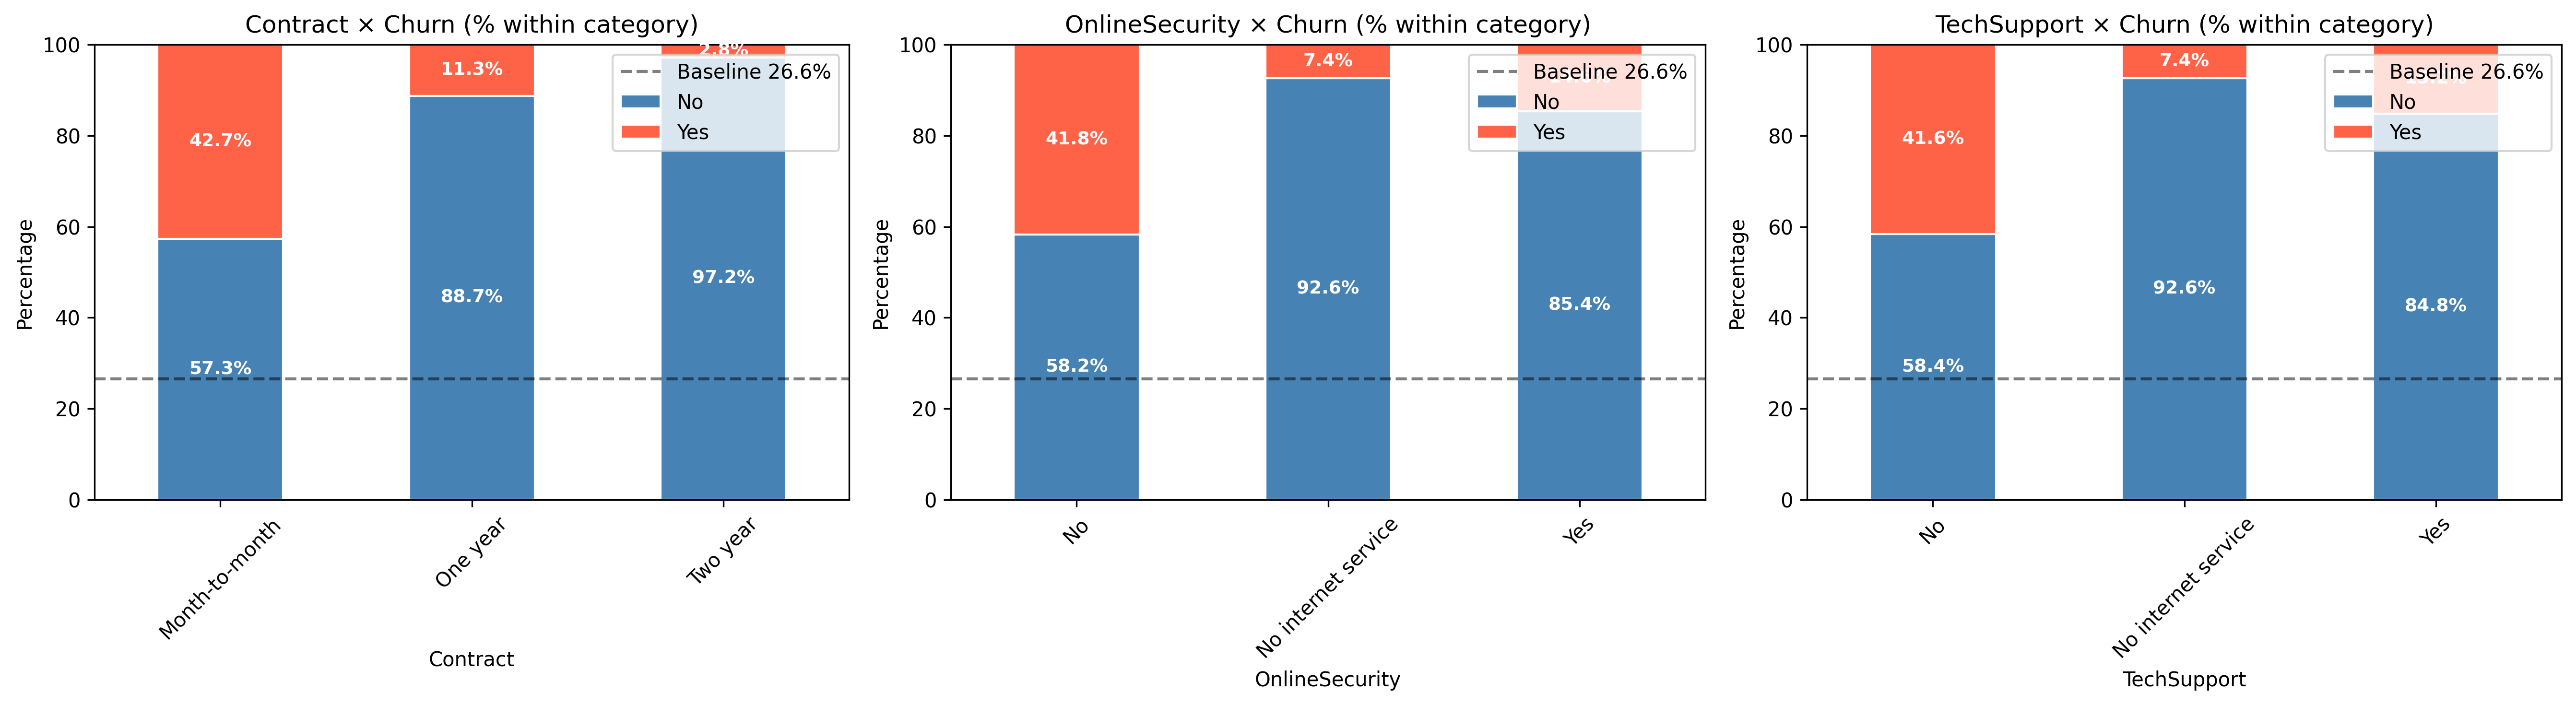

In [5]:
top3 = cramers_table.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top3):

    ct = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    ct = ct[['No', 'Yes']]
    # Plot
    ct.plot(
        kind='bar', stacked=True, ax=ax,
        color=['steelblue', 'tomato'], edgecolor='white')
    # Add labels inside stacked bars
    for container in ax.containers:
        labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

        ax.bar_label(
            container, labels=labels, label_type='center',
            fontsize=9, color='white', fontweight='bold')
    # Baseline
    ax.axhline(
        26.6, color='black', linestyle='--',
        alpha=0.5, label='Baseline 26.6%')
    ax.set_title(f'{feature} × Churn (% within category)')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_top3_stacked_bars.png", dpi=150, bbox_inches="tight")
plt.show()

- **Stacked-bar visualizations confirm the rankings.** For each of the top 3 features, at least one category has a churn rate substantially above the 26.6% baseline:
    - for `Contract` feature Month-to-month contract churn rate is 42.7% — substantially higher that base line vs 2.8% Two-year churn rate — much lower than base line.
    - for `OnlineSecurity` feature without this service churn rate 41.8% — higher than base line vs 15.6% for those customers with the service — lower than baseline.
    - for `TechSupport` feature without this service churn rate 41.6% — than base line vs 15.2% for those customers with the service — lower than baseline.

- TODO — **Feature engineering candidates:**
    - Recode "No internet service" → "No" (6 features)
    - Recode "No phone service" → "No" (MultipleLines)
    - Create `is_auto_pay` binary from PaymentMethod (split manual vs automatic)
    - Create `n_addons` count (sum of how many of the 6 add-ons the customer has) — likely predictive given the stickiness finding
    - Create `is_fiber` binary — the paradox finding suggests fiber deserves its own feature
    - Drop `CustomerID` before modeling
    - Investigate combining OnlineSecurity + TechSupport into a single has_protective_addons feature if they prove redundant.

- **Implications for modeling (carried forward):**
    - The `OnlineSecurity`/`TechSupport` near-tie (combine? keep separate?)
    - The fact that `Contract` dwarfs every other feature (any modeling implication?)
    - The near-zero features — `Gender`, `PhoneService`, `MultipleLines` (drop? keep?)

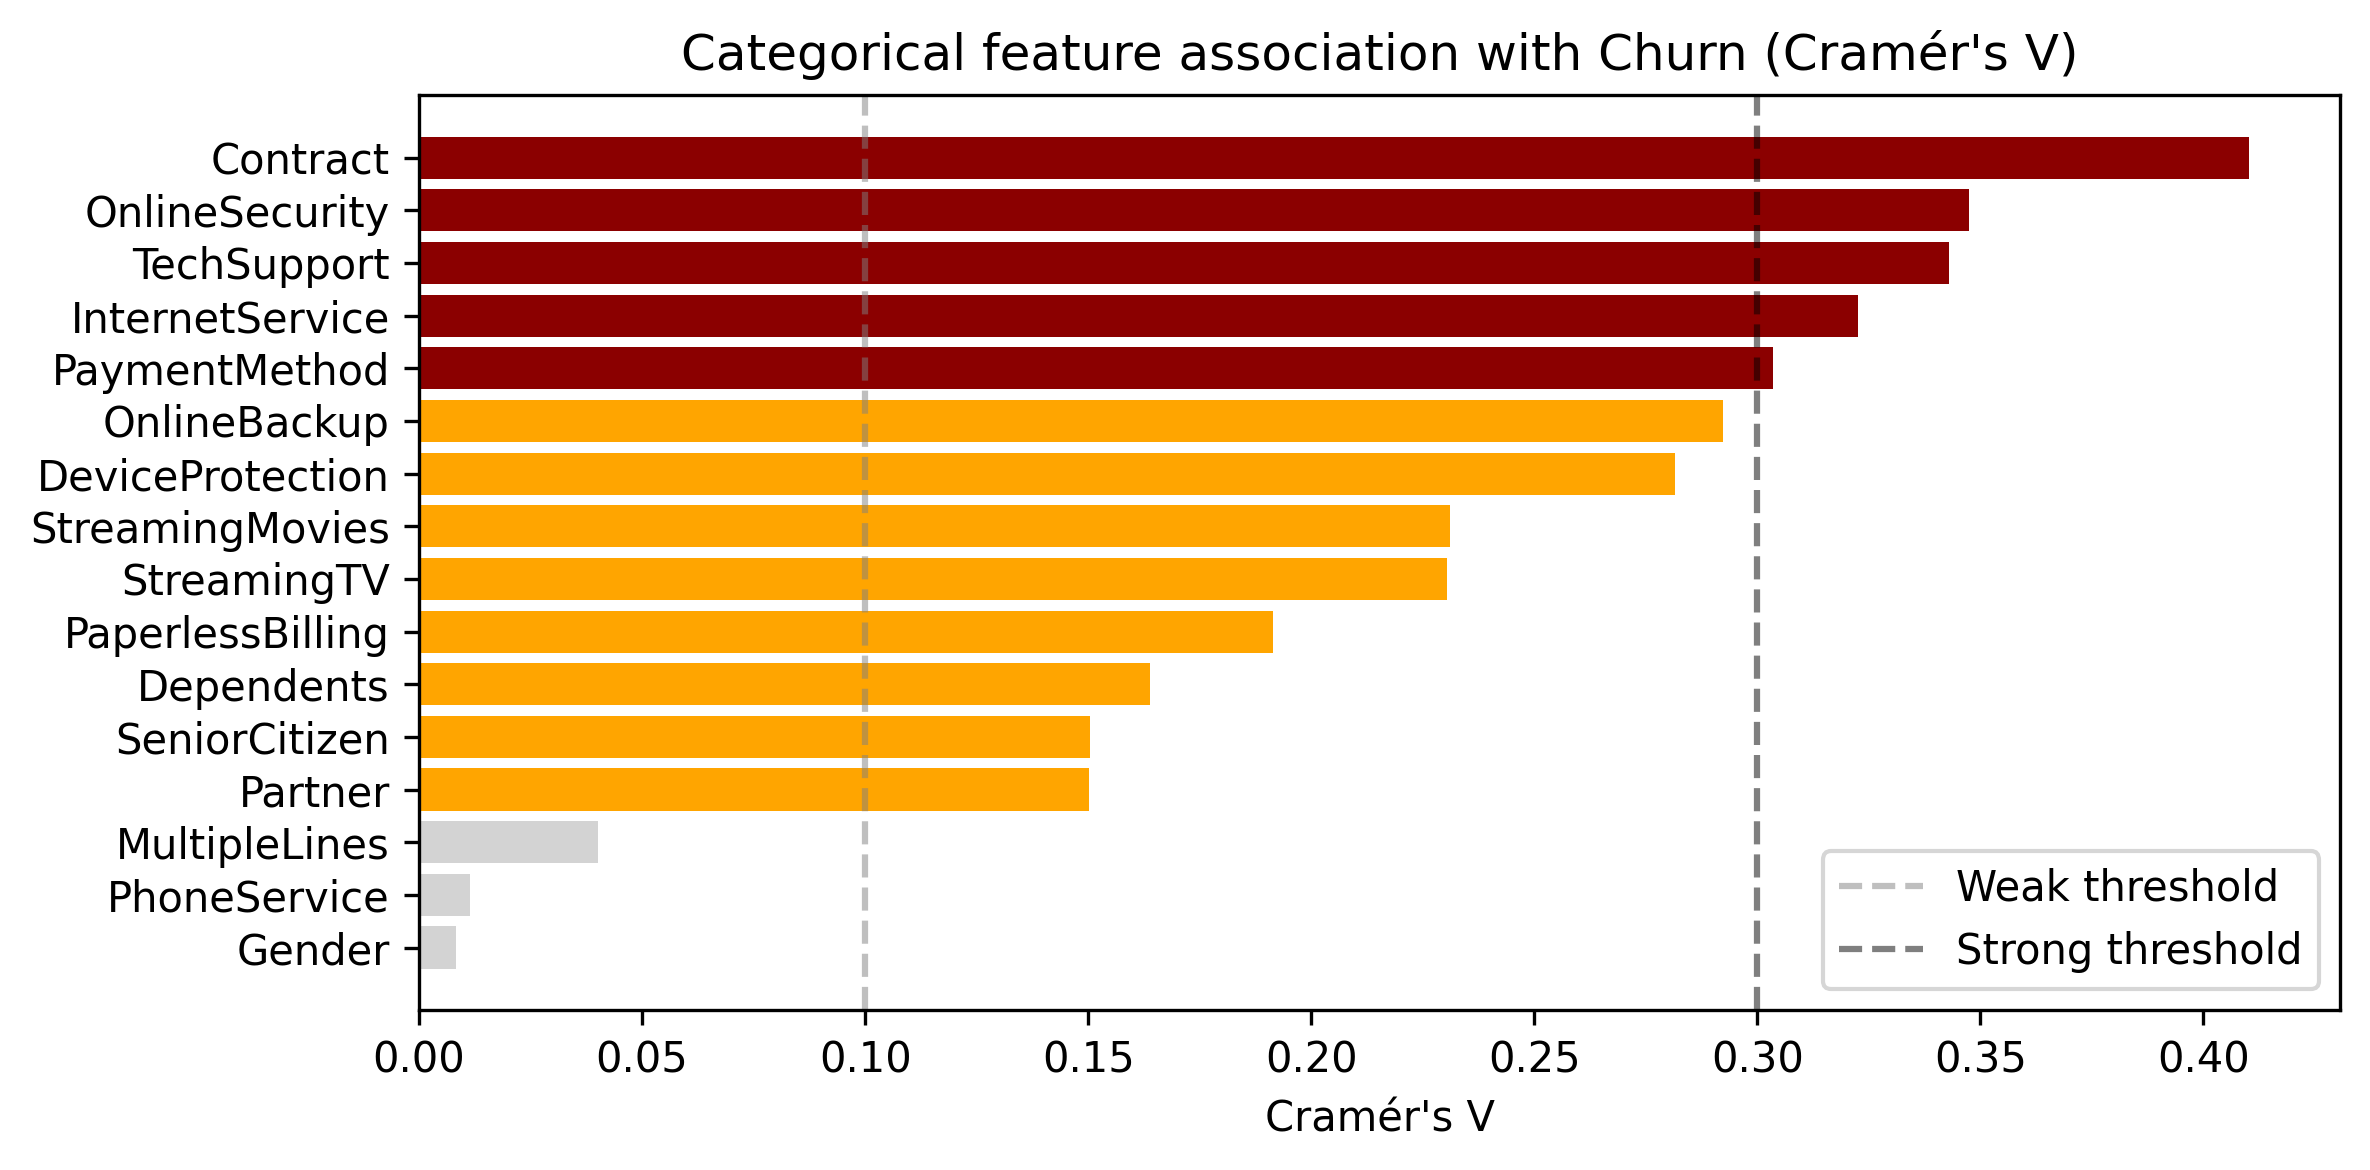

In [6]:
plt.figure(figsize=(8, 4))
colors = ['darkred' if v >= 0.3 else 'orange' if v >= 0.1 else 'lightgray' 
          for v in cramers_table['cramers_v']]
plt.barh(cramers_table['feature'], cramers_table['cramers_v'], color=colors)
plt.gca().invert_yaxis()
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Weak threshold')
plt.axvline(0.3, color='black', linestyle='--', alpha=0.5, label='Strong threshold')
plt.xlabel("Cramér's V")
plt.title("Categorical feature association with Churn (Cramér's V)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_cramers_v_full_ranking.png", dpi=150, bbox_inches='tight')
plt.show()

### Q14. Correlation matrix of numerical features and multicollinearity assessment

#### Numerical Features — `Tenure`, `MonthlyCharges`, `TotalCharges`

**Predictions based on previous analysis**:

- `Tenure` ↔ `TotalCharges`: *very high positive correlation* (**~0.83**), because `TotalCharges ≈ Tenure × MonthlyCharges`. Established in Q10.
- `MonthlyCharges` ↔ `TotalCharges`: *moderate positive correlation*. `Higher monthly bill → faster accumulation of total charges`, but the relationship is muddied by tenure.
- `tenure` ↔ `MonthlyCharges`: *weak positive correlation*. The longer someone has been a customer, the more services they've added over time (slow grade-up), but it's a much weaker relationship.

                Tenure  MonthlyCharges  TotalCharges
Tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


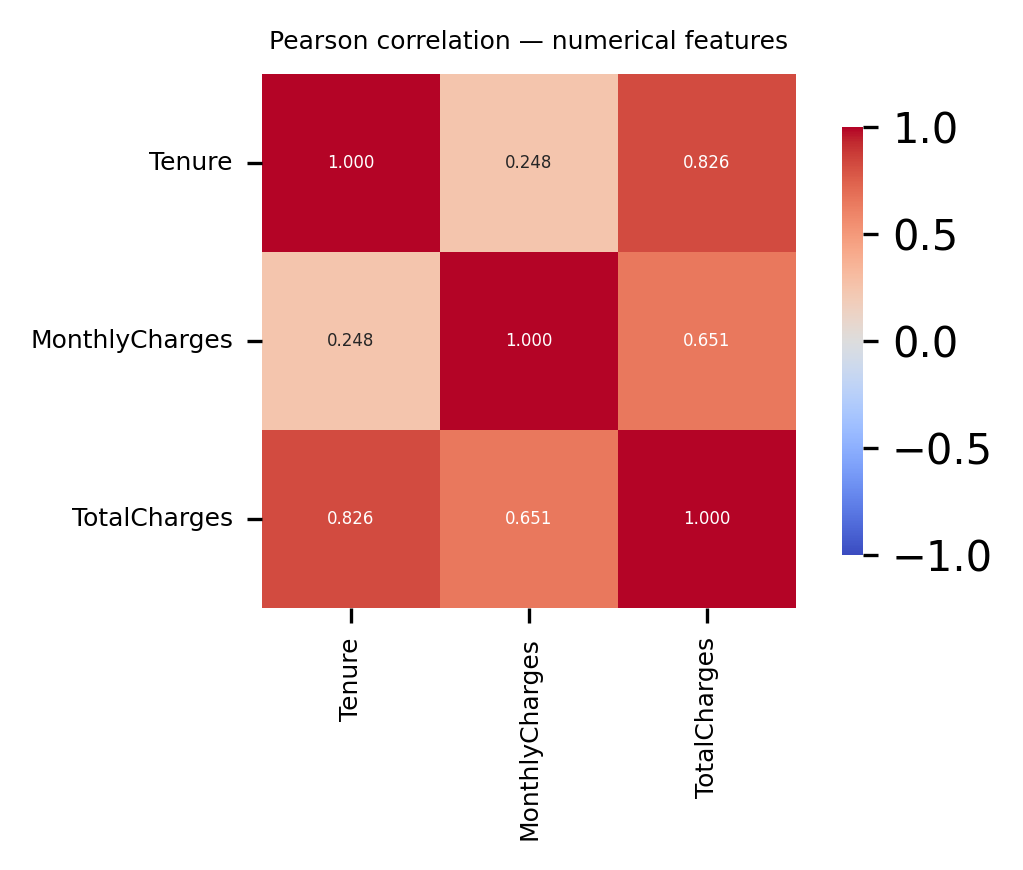

In [7]:
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Correlation matrix
corr_matrix = df[numerical_cols].corr()
print(corr_matrix.round(3))

# Heatmap visualization
plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.3f', square=True,
            annot_kws={"size": 4}, cbar_kws={'shrink': 0.8})
plt.title('Pearson correlation — numerical features', fontsize=6)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_correlation_matrix_numerical.png", dpi=300)
plt.show()

In [8]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(df[numerical_cols])  # adds intercept column at position 0
vif_data = pd.DataFrame({
    'feature': numerical_cols,
    'VIF': [variance_inflation_factor(X.values, i+1) for i in range(len(numerical_cols))]
    # i+1 because index 0 is the constant; we want VIF for features starting at index 1
})
print(vif_data)

          feature       VIF
0          Tenure  5.836728
1  MonthlyCharges  3.216730
2    TotalCharges  9.510931


- **Pairwise correlations** (Pearson, numerical features only):

|                | Tenure | MonthlyCharges | TotalCharges |
|----------------|--------|----------------|--------------|
| Tenure         | 1.000  | 0.248          | `0.826`      |
| MonthlyCharges | 0.248  | 1.000          | `0.651`      |
| TotalCharges   | `0.826`| `0.651`        | 1.000        |

- Two correlations stand out: `0.826` & `0.651`

1. `Tenure` ↔ `TotalCharges` = 0.**83** — very strong positive correlation. This is mechanical: `TotalCharges` accumulates monthly, so longer tenure necessarily means higher `TotalCharges`. This was visually evident in Q10's scatter plot.

2. `MonthlyCharges` ↔ `TotalCharges` = **0.65** — moderate positive correlation. Higher monthly bills produce faster accumulation, but tenure is the dominant driver.

3. `Tenure` ↔ `MonthlyCharges` = **0.25** — weak positive correlation. Customers add services slowly over time, but this is a much weaker effect than the cumulative billing relationship.

- **VIF(Variance Inflation Factor) results**:

1. `Tenure`: 5.83
2. `MonthlyCharges`: 3.22
3. `TotalCharges`: 9.51

- **Implications for modeling**:
* For **logistic regression** (which assumes feature independence for stable coefficient estimates), the `Tenure` ↔ `TotalCharges` relationship is a concern. Including all three features will likely produce:
    * Unstable coefficients with potential sign flips across random seeds.
    * Inflated standard errors, making individual coefficients statistically insignificant despite the model fitting well overall.
    * Reduced interpretability — the "effect of `TotalCharges` holding tenure constant" is not a meaningful question in this data.

- **Planned mitigation**:
    - **Option A (recommended baseline)**: Drop `TotalCharges` from the logistic regression. Keep `Tenure` and `MonthlyCharges` as the two independent numerical predictors.
    - **Option B (worth experimenting)**: Replace `TotalCharges` with a derived `avg_monthly_spend = TotalCharges / max(tenure, 1)` feature, which captures spending intensity without redundancy.
    - **Option C**: For the final model, use a regularized variant (Ridge or Elastic Net) which handles correlated features gracefully.

- For **tree-based models** (*Random Forest*, *XGBoost*), multicollinearity does not degrade predictive accuracy. However, it does distort feature importance — the importance of `Tenure` gets split between `Tenure` and `TotalCharges`. SHAP analysis (planned for Phase 2 evaluation) will reveal the true individual contributions.

- **Carried forward to Q22**: Decision on whether to drop `TotalCharges`, replace it with `avg_monthly_spend`, or keep all three with regularization will be tested empirically in Phase 2 modeling.

### Q15. Phik (φK) matrix across all feature types for unified feature-target ranking

In [17]:
feature_cols = df.columns.drop('CustomerID').tolist()
df[feature_cols].head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- Numerical feature vs Churn analysis — `Tenure` holds the highest-leverage policy varibale for retention.
- Categorical features vs Churn analysis — `Contract` holds the highest-leverage policy varibale for retention.

- **Predicted Top 5 features association with churn (unified across all types):**
    1. `Tenure`
    2. `Contract`
    3. `PaymentMethod`
    4. `OnlineSecurity`
    5. `TechSupport`

- `Tenure` lands on the 1st position.

- Compared to Cramér's V ranking, `PaymentMethod` should be moved upward and be given more significance because **Electronic check customers churn at 45.3%**, by far the highest of any payment method. The other three methods (mailed check, bank transfer, credit card) all cluster around 15–19%.

In [19]:
import phik
from phik.report import plot_correlation_matrix

df_for_phik = df.drop(columns=['CustomerID'])

# Tell phik which columns are numerical (so it bins them)
interval_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Compute phik matrix across ALL features at once
phik_matrix = df_for_phik.phik_matrix(interval_cols=interval_cols)

# Extract just the Churn column and sort — this is your feature ranking
phik_ranking = (phik_matrix['Churn']
                .drop('Churn')                # drop self-correlation
                .sort_values(ascending=False)
                .to_frame('phik_value'))
display(phik_ranking)

,phik_value
Tenure,0.474001
PaymentMethod,0.449125
MonthlyCharges,0.360038
PaperlessBilling,0.295754
TotalCharges,0.278498
Dependents,0.253936
Contract,0.251639
SeniorCitizen,0.233432
Partner,0.232930
OnlineSecurity,0.211840


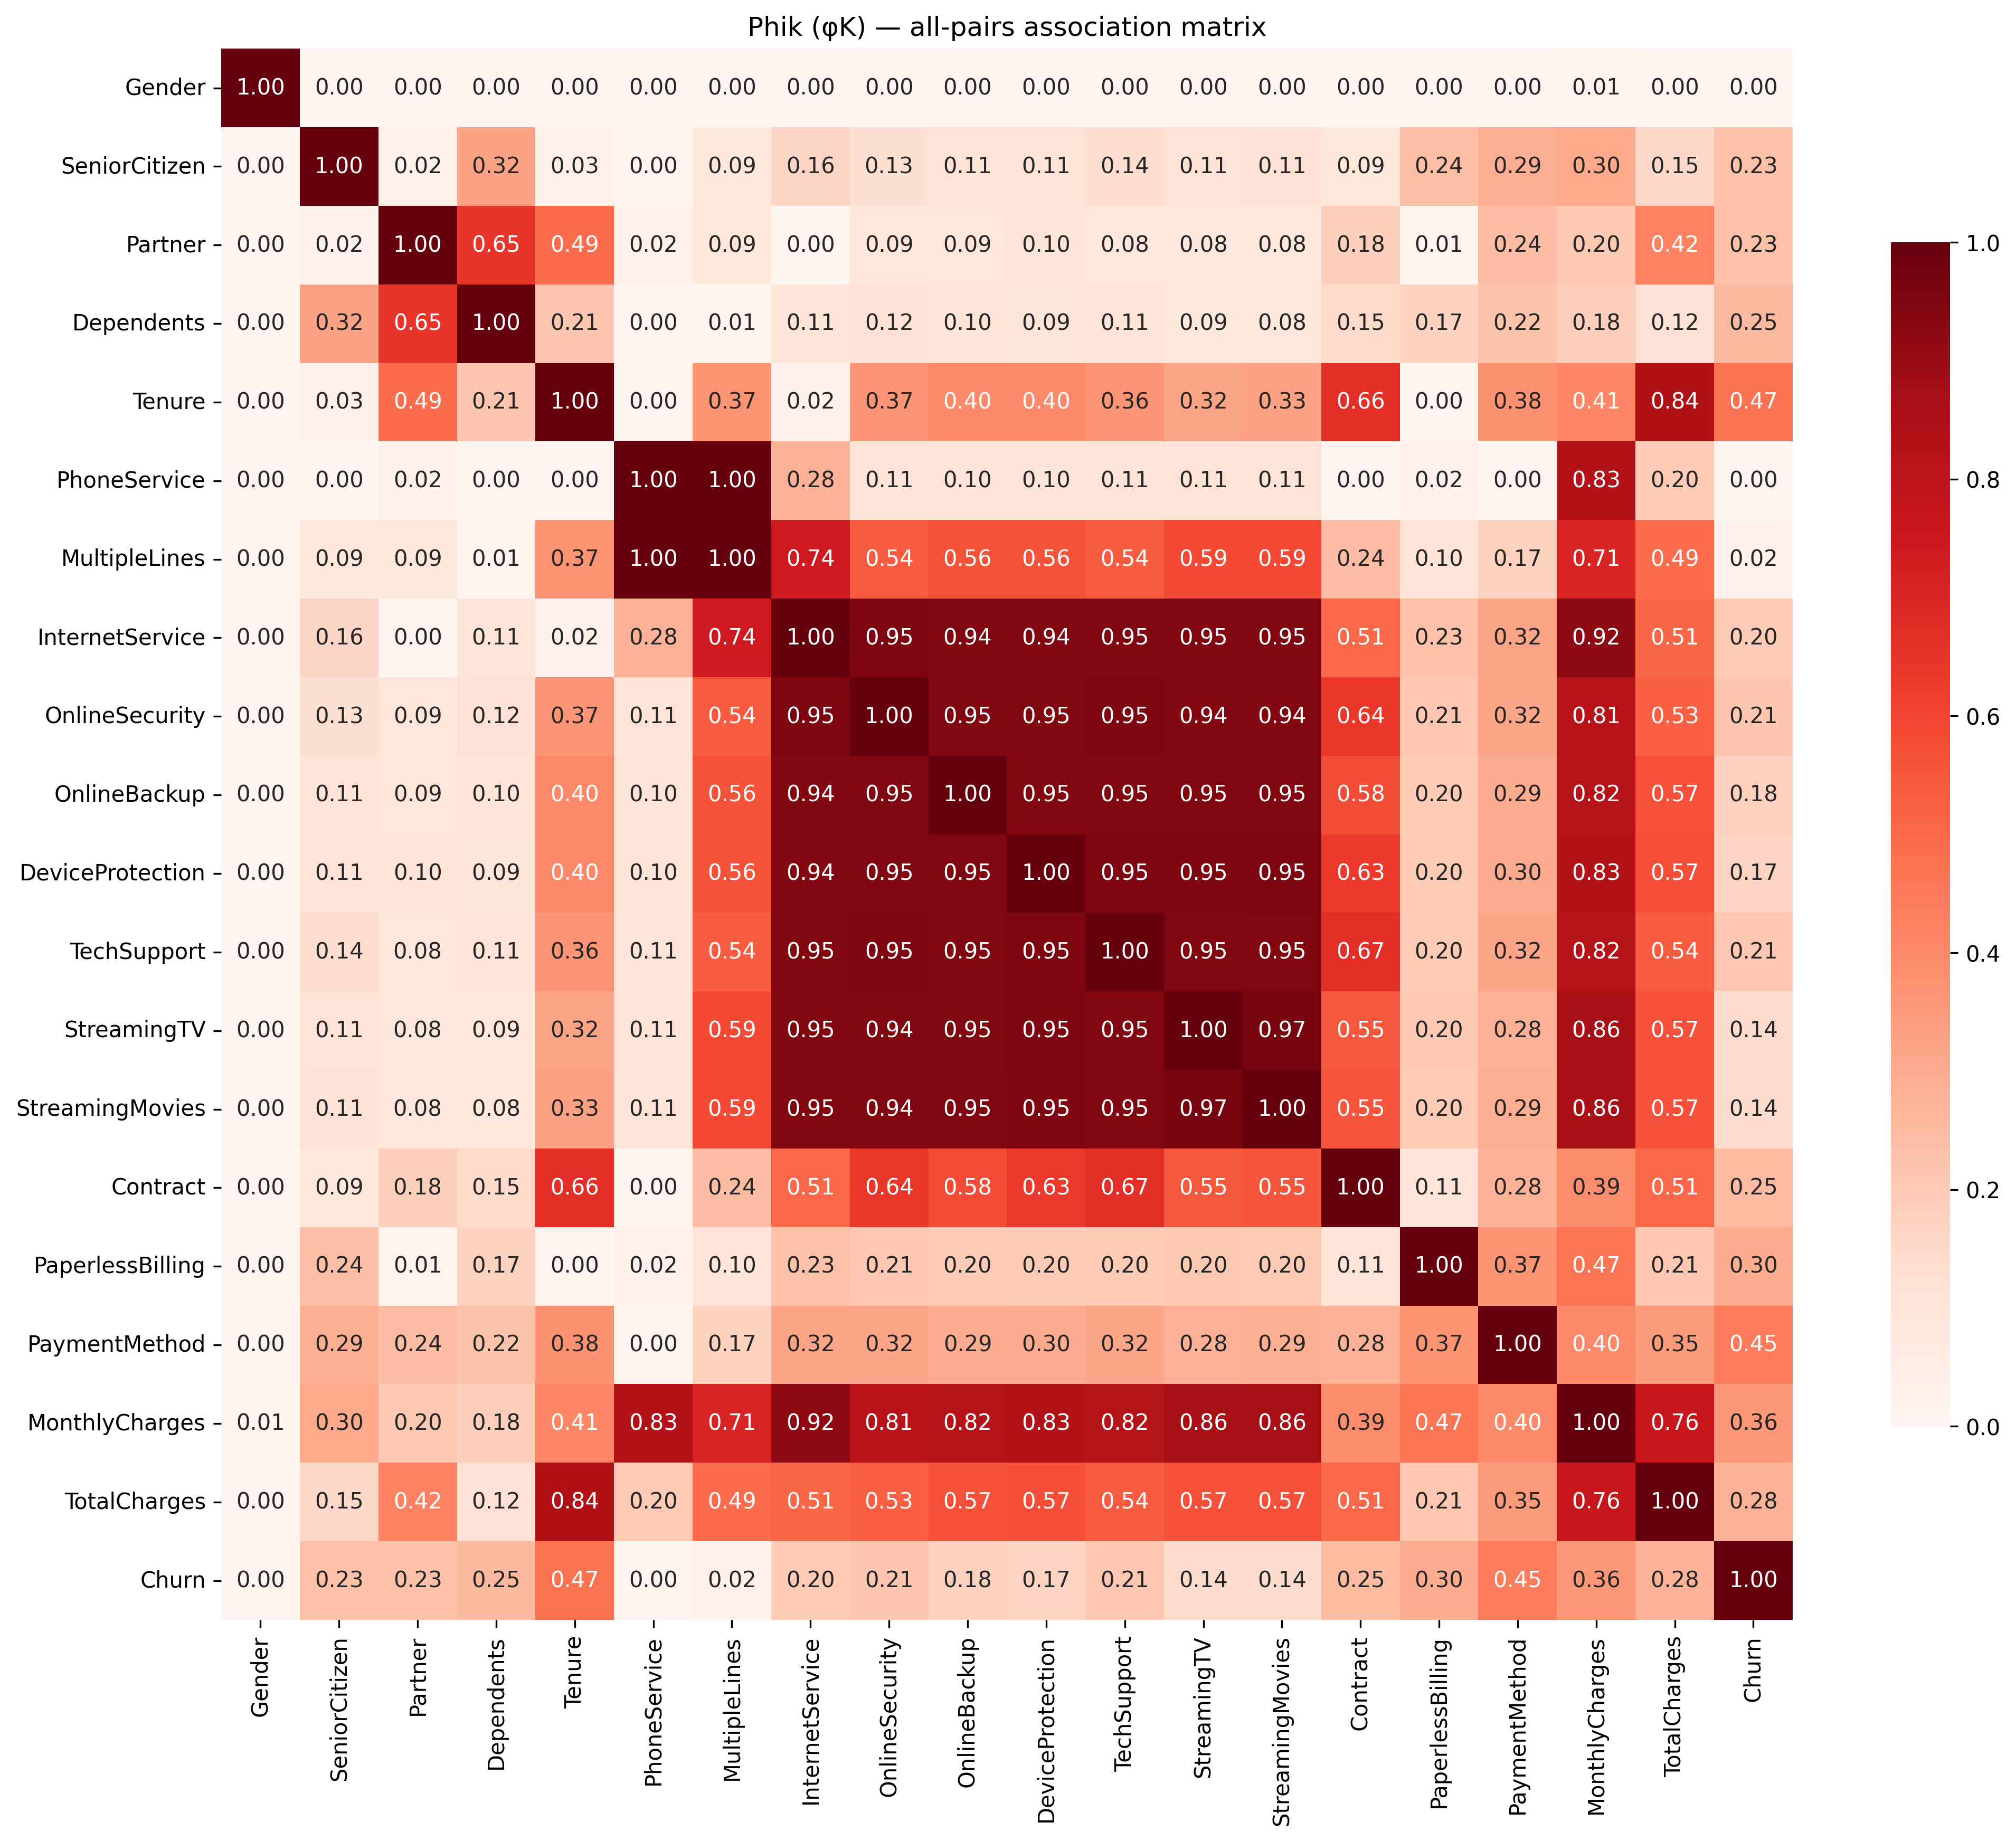

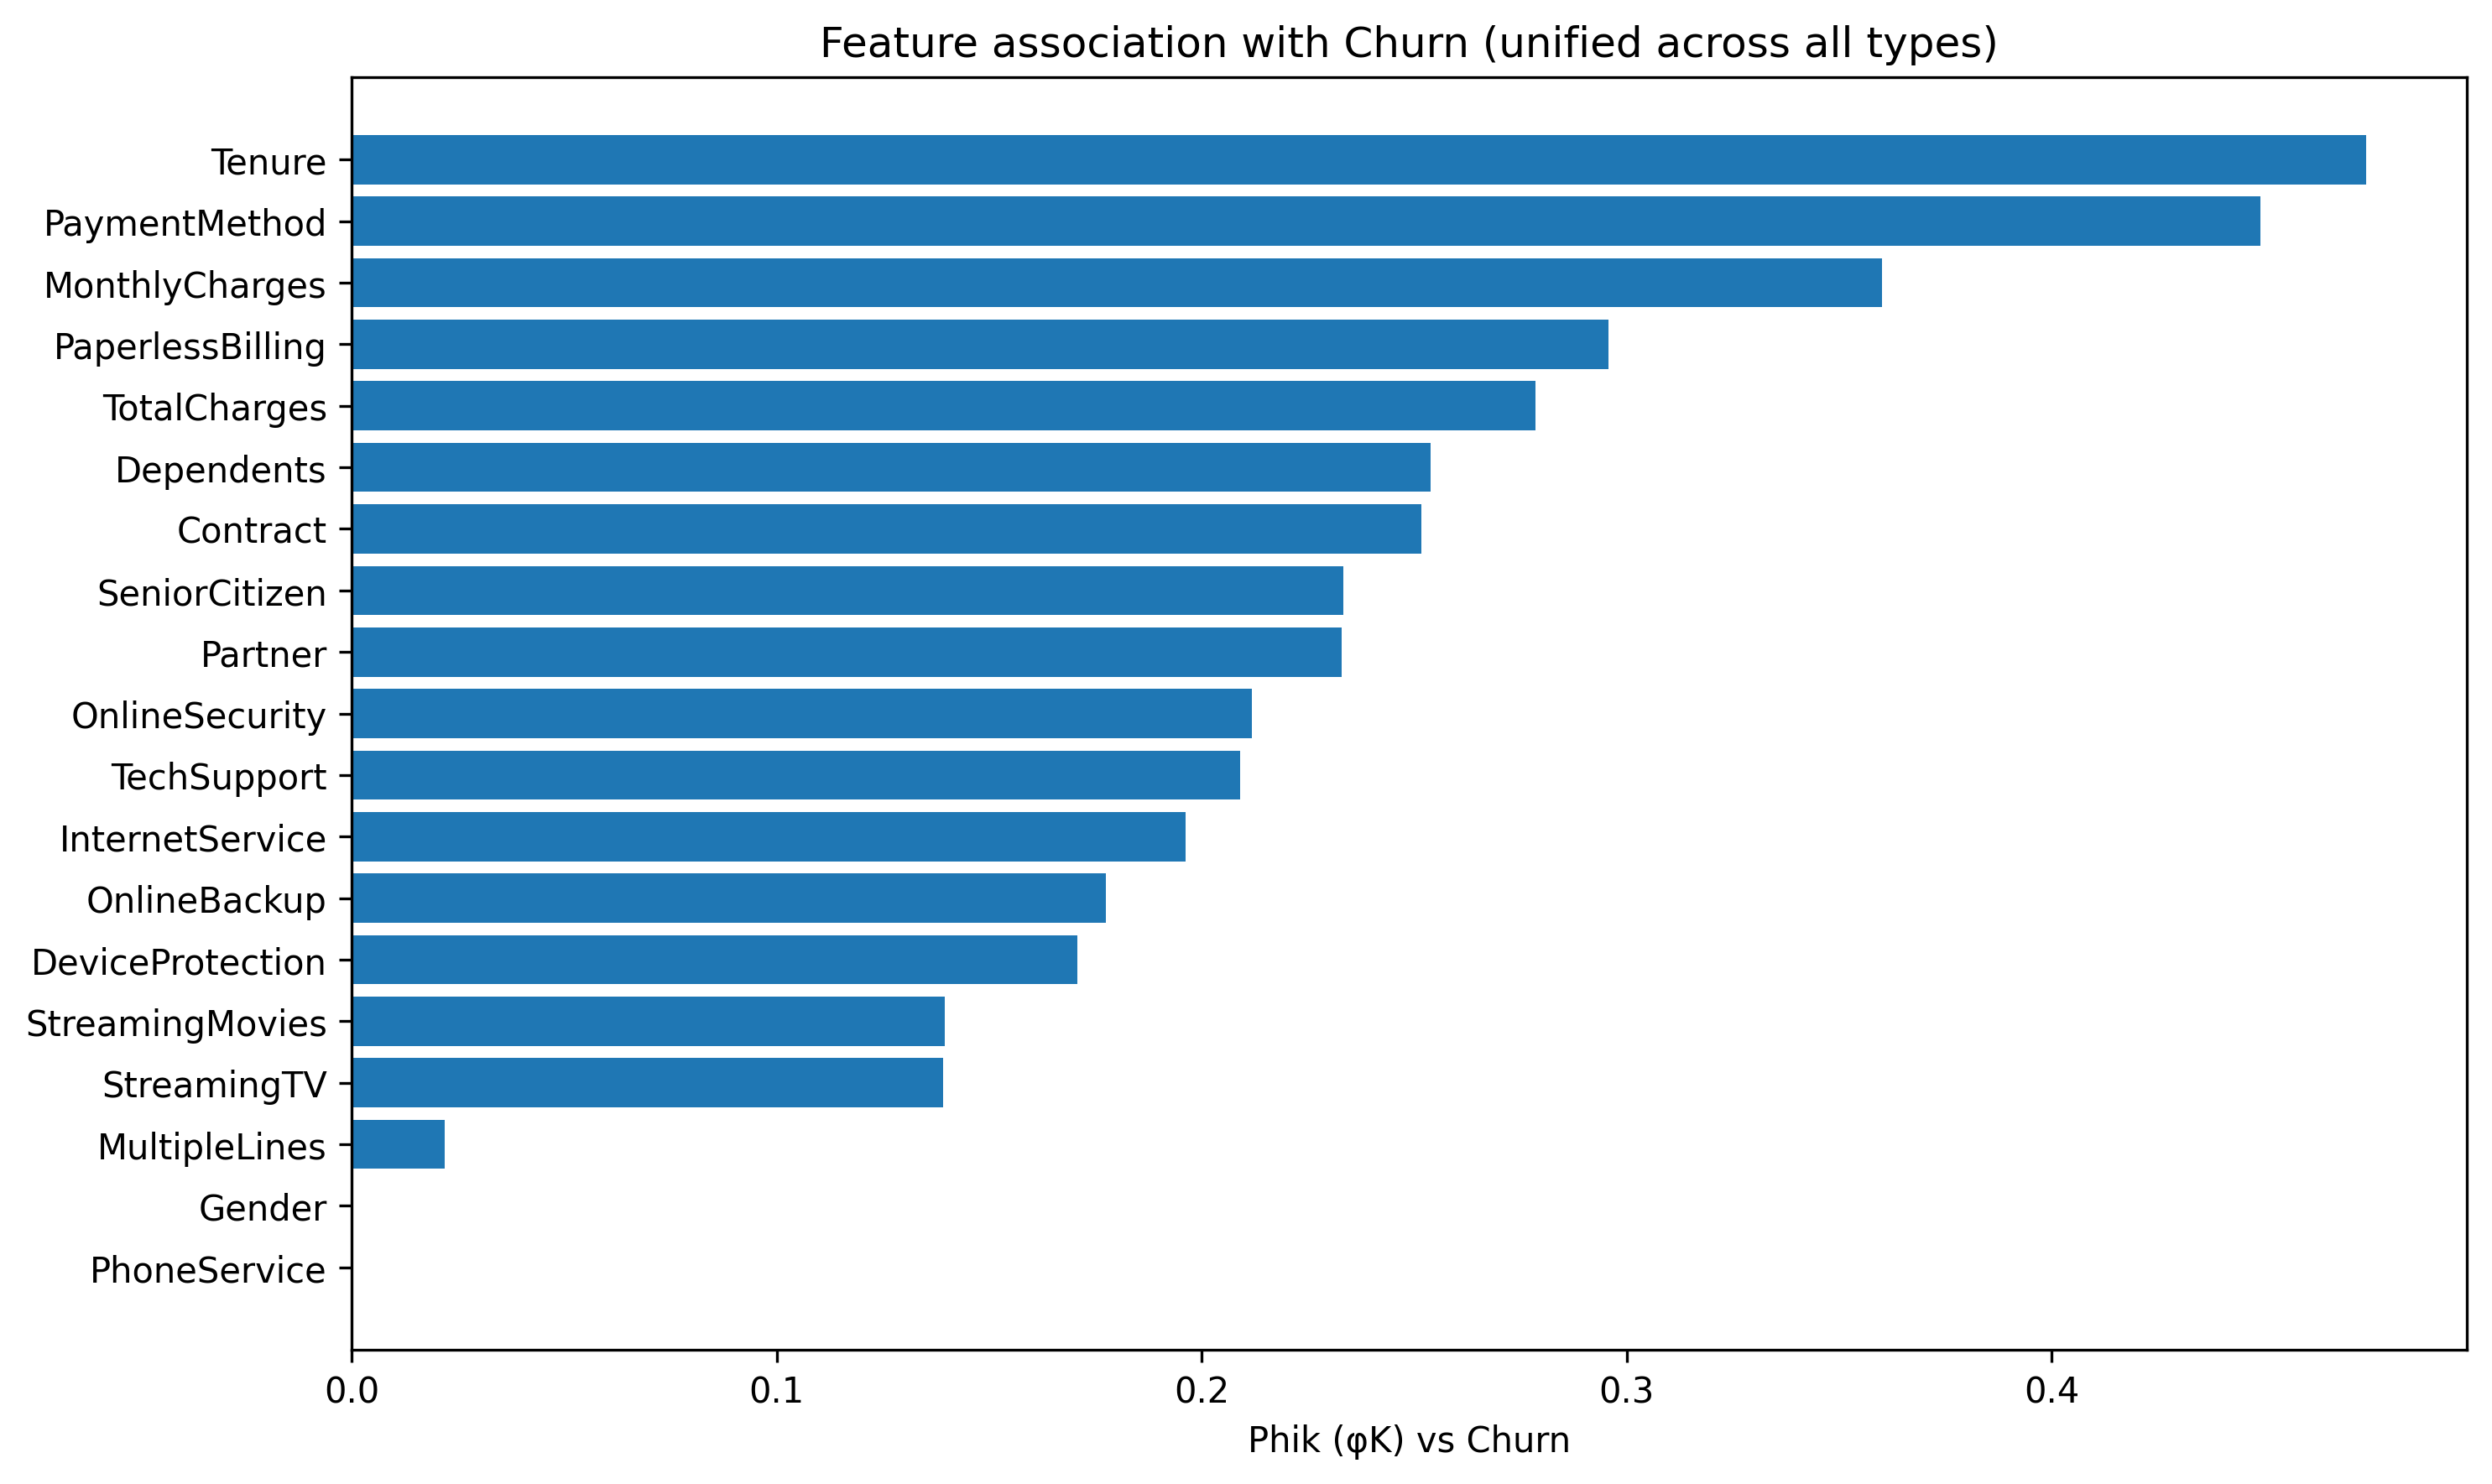

In [13]:
# View 1 — full phik matrix as heatmap (all-pairs)
plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, annot=True, cmap='Reds', vmin=0, vmax=1,
            fmt='.2f', square=True, cbar_kws={'shrink': 0.7})
plt.title('Phik (φK) — all-pairs association matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_phik_full_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# View 2 — feature ranking against Churn (horizontal bar)
plt.figure(figsize=(10, 6))
plt.barh(phik_ranking.index[::-1], phik_ranking['phik_value'][::-1])
plt.xlabel('Phik (φK) vs Churn')
plt.title('Feature association with Churn (unified across all types)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_phik_ranking_vs_churn.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
sig_matrix = df_for_phik.significance_matrix(interval_cols=interval_cols)
sig_churn = sig_matrix['Churn'].drop('Churn').sort_values(ascending=False)
print("\nSignificance (Z-scores) — Churn associations:")
print(sig_churn)


Significance (Z-scores) — Churn associations:
Contract            37.121632
Tenure              30.430947
OnlineSecurity      30.041581
TechSupport         29.658275
InternetService     27.821346
OnlineBackup        25.515643
PaymentMethod       24.744230
DeviceProtection    24.707680
MonthlyCharges      23.614349
StreamingMovies     21.041199
StreamingTV         21.016994
TotalCharges        17.469231
PaperlessBilling    16.381022
Dependents          14.209058
Partner             12.644101
SeniorCitizen       12.131270
MultipleLines        2.695745
PhoneService         0.417519
Gender               0.054452
Name: Churn, dtype: float64


- **Top 5 features association with churn (unified across all types) — phik value:**

|**Rank**|**Feature**|**phik–value**| **Differed from Cramér's V raking**|
|---|---|---|---|
|1.| `Tenure` | 0.474| Numerical featur association was not accounted|
|2.| `PaymentMethod` | 0.449| Was given 4th position with V = 0.303|
|3.| `MonthlyCharges` | 0.360| Numerical featur association was not accounted|
|4.| `PaperlessBilling` | 0.296| Was given 9th position V = 0.191|
|5.| `TotalCharges` | 0.278| Numerical featur association was not accounted|

- **`Tenure` landed at the top position shwoing strongest association with the target feature — `Churn`**:
    - from `Tenure × Churn Box-plot` — Median tenure of *churners* is **10 months vs 38 months** for *retained customers* — a **3.8× ratio** and the ***largest gap*** in the dataset. The IQRs (churner: ~2–29, retained: ~15–61) *barely overlap*.

    - from `Tenure vs TotalCharges scatter-plot` with `hue="Churn"` — confirming that churn is overwhelmingly a phenomenon of new customers who haven't accumulated much billing history. This is consistent with the bimodal tenure finding in  Tenure distribution histogram plot.

    - from `Churn rate by Contract` analysis — Month-to-month churn **(42.7%)** is ***15× higher*** than 2-year contracts **(2.8%)**. That is those customer having less tenure are more prone to churn implies strong association with target.

- **The Cramér's V vs phik comparison**:

  - *For categorical features that appeared in both rankings, the values are not close — and the gap is informative.* Contract collapsed from V = 0.410 (rank 1) to φK = 0.252 (rank 7); OnlineSecurity from V = 0.347 to φK = 0.212; TechSupport from V = 0.343 to φK = 0.209; InternetService from V = 0.323 to φK = 0.196. These are not measurement-noise differences — they are systematic. The likely reason is that phik treats the feature matrix holistically and effectively discounts signal that is shared with other features. Contract's predictive power is largely a re-expression of Tenure (the phik between Contract and Tenure is 0.66), so once Tenure is in the picture, Contract has less *unique* association left with Churn. OnlineSecurity and TechSupport collapse for the same reason — both are entangled with InternetService (φK ≈ 0.95 with InternetService in the all-pairs matrix), and the redundancy is taxed by phik in a way Cramér's V cannot see because Cramér's only ever looks at two columns at a time. Two features moved in the opposite direction: `PaymentMethod` rose from V = 0.303 (rank 5) to φK = 0.449 (rank 2), and `PaperlessBilling` rose from V = 0.191 (rank 10) to φK = 0.296 (rank 4). Both have a strongly non-monotonic relationship to churn (Electronic check is an outlier within PaymentMethod; PaperlessBilling correlates with the tech-savvy / competitor-aware customer profile rather than acting linearly) — and phik is built to catch exactly that kind of non-linear, non-monotonic association, which Cramér's V can capture but does not weight as aggressively.

  - *For numerical features that only appear in phik, the Cramér's V analysis would have missed three of the top five predictors entirely.* Tenure (rank 1, φK = 0.474), MonthlyCharges (rank 3, φK = 0.360), and TotalCharges (rank 5, φK = 0.278) were excluded from the Q13 ranking by construction — Cramér's V only operates on categorical pairs. Had I stopped at Q13, I would have walked into Phase 2 believing Contract was the single most important predictor and would have engineered the feature space around that assumption. The unified ranking corrects this: tenure (in months) carries more raw association with churn than any categorical feature, and Contract's apparent dominance was largely a discretized stand-in for the same underlying signal. This is the central methodological payoff of running phik on top of Cramér's V — not just adding numerical features to the list, but re-weighting the categorical features whose strength was inflated by their correlation with tenure.

- **Significance matrix interpretation (Z-scores from `significance_matrix`)**:

  - Every feature in the top 10 by phik strength is also strongly significant (Z ≫ 3). Contract has the highest Z of any feature (37.1) even though its φK is only 0.252 — this is a case where we are *extremely confident the association is real* but the effect size, after accounting for entanglement with Tenure, is moderate. Tenure (Z = 30.4), OnlineSecurity (30.0), TechSupport (29.7), InternetService (27.8), OnlineBackup (25.5), PaymentMethod (24.7), DeviceProtection (24.7), and MonthlyCharges (23.6) are all robustly significant.

  - The noise-feature check passes cleanly: Gender (Z = 0.054), PhoneService (Z = 0.418), and MultipleLines (Z = 2.70) all fall below the conventional Z > 3 threshold. Gender and PhoneService also have φK = 0, so they are jointly *uninformative and unreliable* — safe to drop. MultipleLines is the interesting borderline case: Z = 2.70 is below significance and φK = 0.022 is essentially zero, so even if a future model assigns it nonzero importance, that importance is almost certainly noise inherited from PhoneService.

  - A "significant but weak" pattern (high Z, low φK) would indicate a real-but-tiny effect that we can detect because we have 7,043 rows but that would not help prediction. The closest example here is SeniorCitizen — Z = 12.1 says the association is unambiguously real, but φK = 0.233 means it carries less than half the predictive weight of Tenure. Worth keeping, but not a top-tier feature.

- **Methodological caveat (phik)**: phik's value depends on the binning applied to numerical features. The `interval_cols` argument tells phik to bin Tenure, MonthlyCharges, and TotalCharges, but the default binning is uniform and the bin count is not chosen by cross-validation — different bin counts can shift Tenure's φK by several hundredths, which matters when features are clustered (Tenure 0.474 vs PaymentMethod 0.449 are close enough that a binning change could re-order them). A more rigorous version of this analysis would either bootstrap the phik values to get confidence intervals around the rankings or run phik twice with different binning schemes and confirm the top-5 set is stable. I am treating the ordering above as directionally reliable rather than precise to three decimals.

- **Forward-looking modeling implications — updates to the Phase 2 feature-engineering plan**:

  - *Add* a non-linear treatment of Tenure. Since Tenure is the strongest single predictor and the histogram (Q8) showed a clear bimodal "new customers vs. lifers" pattern, a raw linear coefficient on Tenure under-captures the signal. Plan a `tenure_bucket` categorical (0–6, 7–24, 25–60, 60+ months) or a `is_new_customer` binary (tenure ≤ 6 months) as a first-class engineered feature, not an afterthought.

  - *Promote* the `is_auto_pay` and `is_electronic_check` binaries from "candidates" to high-priority — PaymentMethod's jump to rank 2 by phik confirms that the manual/automatic split (and specifically the electronic-check anomaly identified in Q12) carries more information than the raw 4-level encoding.

  - *Reconsider* PaperlessBilling. The original FE plan treated it as a likely-to-drop proxy variable. Its rank-4 phik (0.296, Z = 16.4) is too strong to discard without testing. Keep it in the baseline feature set and let regularization decide.

  - *Reinforce* the OnlineSecurity + TechSupport consolidation already proposed in Q13. The phik matrix shows them with near-identical values against Churn (0.212 vs 0.209) and a φK of 0.95 with each other through their shared link to InternetService. Building a `n_protective_addons` count, or an `has_any_protection` binary, is now well-supported.

  - *Confirm the drop list* with higher confidence: Gender, PhoneService, and MultipleLines all have φK ≈ 0 and Z below the significance threshold. Dropping them is safe.

  - *Linear-model warning carried forward from Q14*: TotalCharges (φK with Tenure = 0.84, VIF = 9.51) and Contract (φK with Tenure = 0.66) both share heavy variance with Tenure. For logistic regression specifically, keeping Tenure and dropping at least one of {Contract, TotalCharges} — or moving to Ridge/Elastic Net — remains the right call. For tree-based models the redundancy is harmless for accuracy but will split feature importance across the cluster, so SHAP rather than raw importance should be the interpretation tool in Phase 3.